In [49]:
import os
import pandas as pd

df = pd.read_csv("/work/upthomae/Meng/tricomplex-design_2026/2026_Apr_ligand_delta_scores/8VLB_A_3JF_A_deduplicated.csv", nrows=100)
df.head()

,target,target_path,target_site,target_vix,matched_protein,matched_patch_id,matched_protein_path,score,desc_dist_score,clashing_ca,...,iface_transmembrane_frac,iface_plddt,iface_n_sse,iface_n_helix,iface_n_strand,iface_helix_frac,iface_strand_frac,cluster_id,cluster_size,cluster_mean_rmsd
0,8VLB_A,/scratch/ymeng/tricomplex-design_Meng/data/sea...,site_18,2615,A0A024RBG1-F1-nD1_A,27,/scratch/ymeng/tricomplex-design_Meng/data/sea...,0.9499,24.638342,0,...,0.0,0.0,4.0,1.0,2.0,0.437500,0.375000,41594.0,2.0,0.140756
1,8VLB_A,/scratch/ymeng/tricomplex-design_Meng/data/sea...,site_5,2641,A0A024RBG1-F1-nD1_A,32,/scratch/ymeng/tricomplex-design_Meng/data/sea...,0.9269,13.864248,0,...,0.0,0.0,4.0,2.0,1.0,0.538462,0.076923,41595.0,1.0,0.000000
2,8VLB_A,/scratch/ymeng/tricomplex-design_Meng/data/sea...,site_15,2532,A0A087WUV0-F1-nD2_A,14,/scratch/ymeng/tricomplex-design_Meng/data/sea...,0.9053,20.354840,0,...,0.0,0.0,6.0,2.0,1.0,0.615385,0.153846,33587.0,1.0,0.000000
3,8VLB_A,/scratch/ymeng/tricomplex-design_Meng/data/sea...,site_21,3484,A0A087WUV0-F1-nD2_A,7,/scratch/ymeng/tricomplex-design_Meng/data/sea...,0.9331,19.006990,0,...,0.0,0.0,6.0,2.0,1.0,0.454545,0.090909,33588.0,1.0,0.000000
4,8VLB_A,/scratch/ymeng/tricomplex-design_Meng/data/sea...,site_1,3048,A0A087WUV0-F1-nD3_A,0,/scratch/ymeng/tricomplex-design_Meng/data/sea...,0.9172,16.835910,0,...,0.0,0.0,4.0,1.0,0.0,0.500000,0.000000,33589.0,1.0,0.000000


In [19]:
pd.set_option('display.max_rows', None)
df.iloc[0]

target                                                                     8VLB_A
target_path                     /scratch/ymeng/tricomplex-design_Meng/search_a...
target_site                                                               site_33
target_vix                                                                   2615
matched_protein                                               A0A024RBG1-F1-nD1_A
matched_patch_id                                                               42
matched_protein_path            /scratch/ymeng/tricomplex-design_Meng/search_a...
score                                                                       0.955
desc_dist_score                                                          25.24845
clashing_ca                                                                     0
clashing_heavy                                                                  5
matched_vix                                                                  2939
desc_dist       

In [21]:
# read only columns 8 and 9
df = pd.read_csv("/work/upthomae/Meng/tricomplex-design_2026/2026_March/8VLB_A_3JF_A/8VLB_A_3JF_A_deduplicated.csv", usecols=[4, 7, 8, 12, 96])
df.head()


,matched_protein,score,desc_dist_score,desc_dist,cluster_size
0,A0A024RBG1-F1-nD1_A,0.9550,25.248450,1.753555,3.0
1,A0A024RBG1-F1-nD1_A,0.9520,14.095269,1.990063,1.0
2,A0A075B759-F1-nD1_A,0.9097,17.042883,1.930622,1.0
3,A0A075B767-F1-nD1_A,0.9654,18.656336,1.857725,1.0
4,A0A087WUV0-F1-nD3_A,0.9230,17.234636,1.980172,1.0


In [29]:
# Count the number of unique matched_protein in df
df["matched_protein"].nunique()

19809

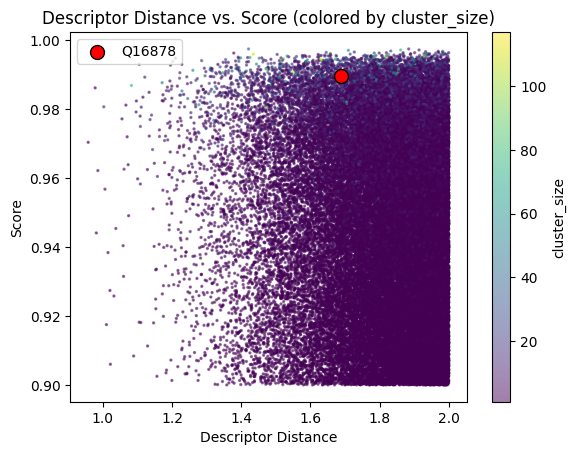

In [32]:
# Plot desc_dist ~ score, colored by cluster_size, highlight 'Q16878'
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# Main scatter plot
scatter = ax.scatter(
    df["desc_dist"], 
    df["score"], 
    c=df["cluster_size"], 
    cmap='viridis', 
    alpha=0.5, 
    s=2
)

# Highlight the row where matched_protein contains "Q16878"
highlight = df[df["matched_protein"].astype(str).str.contains("Q16878")]
if not highlight.empty:
    ax.scatter(
        highlight["desc_dist"], 
        highlight["score"], 
        color='red', 
        s=100, 
        edgecolors='black', 
        label='Q16878'
    )

ax.set_xlabel("Descriptor Distance")
ax.set_ylabel("Score")
ax.set_title("Descriptor Distance vs. Score (colored by cluster_size)")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('cluster_size')
if not highlight.empty:
    ax.legend()

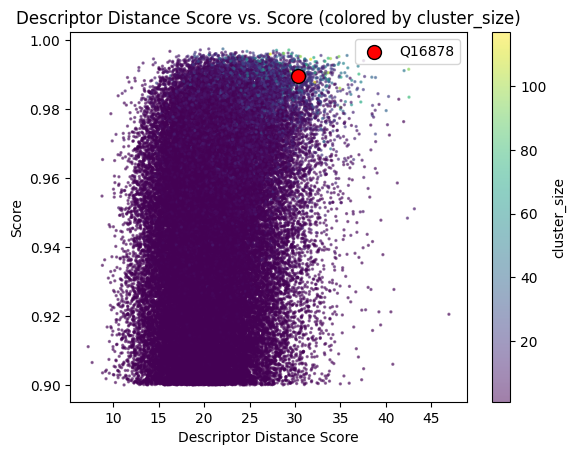

In [33]:
# Plot desc_dist_score ~ score, colored by cluster_size, highlight 'Q16878'
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# Main scatter plot
scatter = ax.scatter(
    df["desc_dist_score"], 
    df["score"], 
    c=df["cluster_size"], 
    cmap='viridis', 
    alpha=0.5, 
    s=2
)

# Highlight the row where matched_protein contains "Q16878"
highlight = df[df["matched_protein"].astype(str).str.contains("Q16878")]
if not highlight.empty:
    ax.scatter(
        highlight["desc_dist_score"], 
        highlight["score"], 
        color='red', 
        s=100, 
        edgecolors='black', 
        label='Q16878'
    )

ax.set_xlabel("Descriptor Distance Score")
ax.set_ylabel("Score")
ax.set_title("Descriptor Distance Score vs. Score (colored by cluster_size)")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('cluster_size')
if not highlight.empty:
    ax.legend()

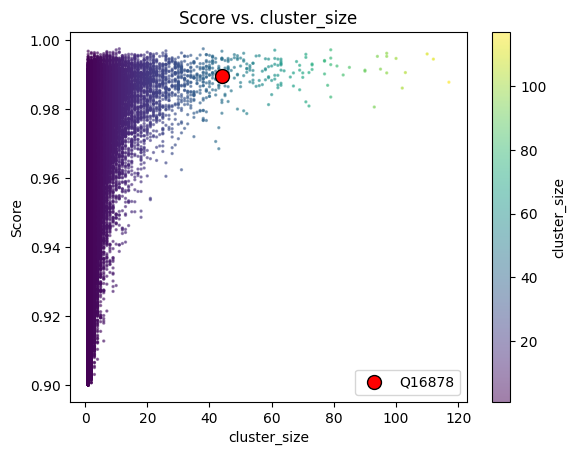

In [31]:
# Plot Score vs. cluster_size, colored by cluster_size, highlight 'Q16878'
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# Main scatter plot
scatter = ax.scatter(
    df["cluster_size"], 
    df["score"], 
    c=df["cluster_size"], 
    cmap='viridis', 
    alpha=0.5, 
    s=2
)

# Highlight the row where matched_protein contains "Q16878"
highlight = df[df["matched_protein"].astype(str).str.contains("Q16878")]
if not highlight.empty:
    ax.scatter(
        highlight["cluster_size"], 
        highlight["score"], 
        color='red', 
        s=100, 
        edgecolors='black', 
        label='Q16878'
    )

ax.set_xlabel("cluster_size")
ax.set_ylabel("Score")
ax.set_title("Score vs. cluster_size")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('cluster_size')
if not highlight.empty:
    ax.legend()

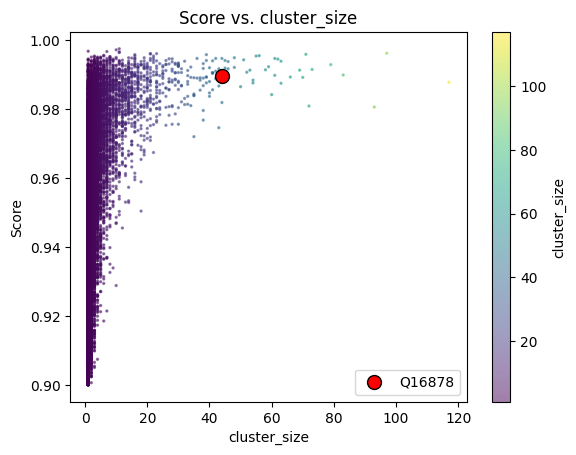

In [45]:
# Randomly sample 5000 unique matched_protein ids
sampled_proteins = df["matched_protein"].drop_duplicates().sample(n=5000, random_state=42)

# Ensure the id(s) containing 'Q16878' is/are included (as Series, not a string)
q16878_proteins = df["matched_protein"][df["matched_protein"].astype(str).str.contains("Q16878")].drop_duplicates()
# Combine sampled and Q16878, drop duplicates just in case
sampled_proteins = pd.concat([sampled_proteins, q16878_proteins]).drop_duplicates()

df_sampled = df[df["matched_protein"].isin(sampled_proteins)]

# Plot Score vs. cluster_size, colored by cluster_size, highlight 'Q16878'
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# Main scatter plot
scatter = ax.scatter(
    df_sampled["cluster_size"], 
    df_sampled["score"], 
    c=df_sampled["cluster_size"], 
    cmap='viridis', 
    alpha=0.5, 
    s=2
)

# Highlight the row where matched_protein contains "Q16878"
highlight = df_sampled[df_sampled["matched_protein"].astype(str).str.contains("Q16878")]
if not highlight.empty:
    ax.scatter(
        highlight["cluster_size"], 
        highlight["score"], 
        color='red', 
        s=100, 
        edgecolors='black', 
        label='Q16878'
    )

ax.set_xlabel("cluster_size")
ax.set_ylabel("Score")
ax.set_title("Score vs. cluster_size")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('cluster_size')
if not highlight.empty:
    ax.legend()




In [47]:
# Write sampled_proteins to a text file
out_path = "/scratch/ymeng/NNeosurf/masif-neosurf/data/8VLB_domainome_sampled_hits.txt"
with open(out_path, "w") as f:
    for protein in sampled_proteins:
        f.write(protein + "\n")


